# 선형 회귀 직접 구현 (Linear Regression from Scratch)
**주제**: 경사하강법(Gradient Descent)을 이용한 선형 회귀 직접 구현 (sklearn 미사용)

---

## 개요

1. sklearn의 **당뇨병 데이터셋**을 불러오고 BMI 피처만 추출
2. **sklearn LinearRegression**으로 기준(baseline) 모델 학습
3. **경사하강법(Gradient Descent)** 으로 선형 회귀 직접 구현
4. 결과 비교 및 손실(loss) 곡선 시각화

### 모델
$$\hat{y} = W \cdot x + b$$

### 손실 함수 (MSE)
$$L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

### 경사하강법 업데이트 규칙
$$\frac{\partial L}{\partial W} = \frac{2}{n} \sum (\hat{y} - y) \cdot x \qquad
\frac{\partial L}{\partial b} = \frac{2}{n} \sum (\hat{y} - y)$$

$$W \leftarrow W - \alpha \frac{\partial L}{\partial W}, \quad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$


---
## 1. 라이브러리 임포트 및 데이터 로드

* sklearn에 내장된 당뇨병 데이터셋 사용
  * 442개 샘플, 10개 피처
  * 타깃(y): 혈당 수치

* 1차원 선형 회귀를 위해 BMI 선택
  * index = 2
  * random_state=0
  * 90% 학습 / 10% 테스트




In [1]:
import matplotlib.pylab as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split

# 당뇨병 데이터셋 로드
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

# BMI 피처(index=2)만 선택 후 2D 배열로 변환
diabetes_X_new = diabetes_X[:, np.newaxis, 2]

# 학습(90%) / 테스트(10%) 분리
X_train, X_test, y_train, y_test = train_test_split(
    diabetes_X_new, diabetes_y, test_size=0.1, random_state=0
)

print(f"학습 데이터 크기: {len(X_train)}, 테스트 데이터 크기: {len(X_test)}")


학습 데이터 크기: 397, 테스트 데이터 크기: 45


---
## 2. 기준 모델: sklearn LinearRegression

*   경사하강법을 직접 구현하기 전에, sklearn의 `LinearRegression`으로 먼저 학습함.
*   이 결과를 비교 기준(reference) 으로 사용하며, 직접 구현한 W와 b가  
이 값에 수렴하는지 확인함.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54792 (\N{HANGUL SYLLABLE HYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

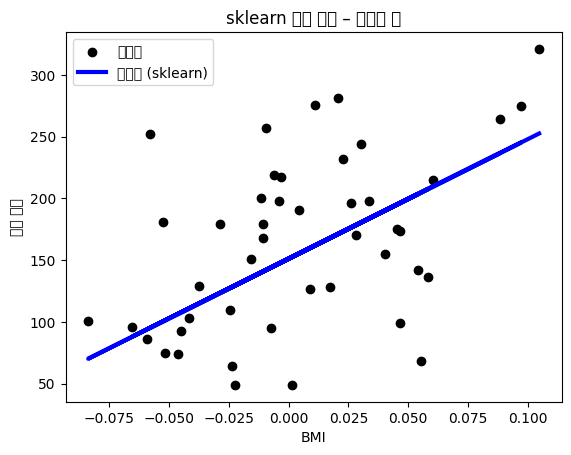

In [2]:
# sklearn 선형 회귀 학습
regr = LinearRegression()
regr.fit(X_train, y_train)

# 테스트 데이터 예측
y_pred_sklearn = regr.predict(X_test)

# 실제값 vs 예측값 시각화
plt.scatter(X_test, y_test, color='black', label='실제값')
plt.plot(X_test, y_pred_sklearn, color='blue', linewidth=3, label='예측값 (sklearn)')
plt.title("sklearn 선형 회귀 – 테스트 셋")
plt.xlabel("BMI")
plt.ylabel("혈당 수치")
plt.legend()
plt.show()


In [3]:
# sklearn으로 학습된 파라미터 (나중에 우리 결과와 비교)
print(f"[sklearn 기준값]  W = {regr.coef_[0]:.4f},  b = {regr.intercept_:.4f}")


[sklearn 기준값]  W = 966.7269,  b = 151.2093


---
## 3. 경사하강법을 위한 데이터 전처리

 직접 구현하는 GD 반복문에서 요소별(element-wise) 연산을 편리하게 수행하기 위해 `X_train` / `X_test`의 형태를 `(n, 1)` → `(n,)` 로 변환함.  


In [4]:
# (n, 1) → (n,) 로 변환
X_train = X_train[:, 0]
X_test  = X_test[:, 0]

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


X_train shape: (397,), X_test shape: (45,)


---
## 4. 경사하강법으로 선형 회귀 직접 구현

매 epoch마다 아래 4단계를 반복함:

| 단계 | 설명 |
|------|------|
| **순전파 (Forward pass)** | 현재 W, b로 예측값 $\hat{y} = Wx + b$ 계산 |
| **손실 계산 (Loss)** | MSE 계산 후 기록 |
| **역전파 (Backward pass)** | $\partial L / \partial W$, $\partial L / \partial b$ 계산 |
| **파라미터 업데이트** | $W \leftarrow W - \alpha \cdot dW$, $b \leftarrow b - \alpha \cdot db$ |

***하이퍼파라미터**: `epochs = 25000`, `learning_rate = 0.1`


In [5]:
# ── 하이퍼파라미터 설정 ──────────────────────────────────────────
epochs = 25000
lr     = 0.1          # 학습률 (learning rate)
n      = float(len(X_train))  # 학습 샘플 수

# ── 가중치 랜덤 초기화 ───────────────────────────────────────────
np.random.seed(42)
W = np.random.rand()
b = np.random.rand()

train_loss = []  # epoch별 손실값 저장

# ── 학습 반복문 ──────────────────────────────────────────────────
for k in range(epochs):

    # 1. 순전파: 예측값 계산
    y_pred_train = W * X_train + b

    # 2. MSE 손실 계산 및 기록
    loss = (1 / n) * np.sum((y_pred_train - y_train) ** 2)
    train_loss.append(loss)

    # 3. 기울기(gradient) 계산 - MSE를 W, b에 대해 편미분
    dW = (2 / n) * np.sum((y_pred_train - y_train) * X_train)
    db = (2 / n) * np.sum(y_pred_train - y_train)

    # 4. 파라미터 업데이트 (gradient 반대 방향으로 이동)
    W = W - lr * dW
    b = b - lr * db

print("학습 완료!")


학습 완료!


---
## 5. 학습된 파라미터 확인

* 경사하강법으로 학습된 W, b를 sklearn의 기준값과 비교함.  
* 두 값이 거의 일치하면 구현이 올바른 것임.


In [6]:
print("학습된 파라미터 (경사하강법)")
print(f"  W = {W:.4f}")
print(f"  b = {b:.4f}")
print()
print(f"[비교 기준 – sklearn]  W = {regr.coef_[0]:.4f},  b = {regr.intercept_:.4f}")


학습된 파라미터 (경사하강법)
  W = 966.7169
  b = 151.2093

[비교 기준 – sklearn]  W = 966.7269,  b = 151.2093


---
## 6. 결과 시각화

### 6-1. 학습 데이터에서의 회귀선


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


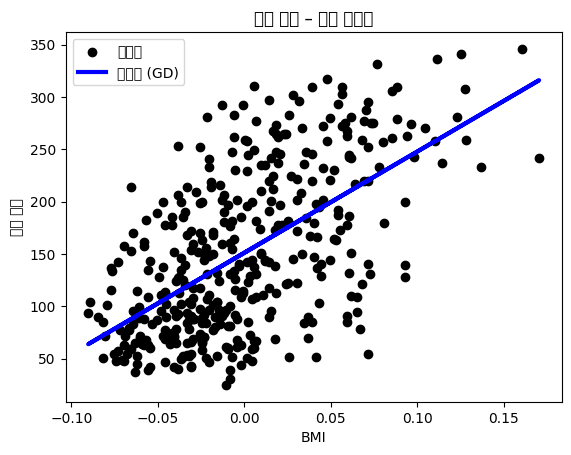

In [7]:
y_pred_train_final = W * X_train + b

plt.scatter(X_train, y_train, color='black', label='실제값')
plt.plot(X_train, y_pred_train_final, color='blue', linewidth=3, label='예측값 (GD)')
plt.title("선형 회귀 – 학습 데이터")
plt.xlabel("BMI")
plt.ylabel("혈당 수치")
plt.legend()
plt.show()


### 6-2. 테스트 데이터에서의 회귀선


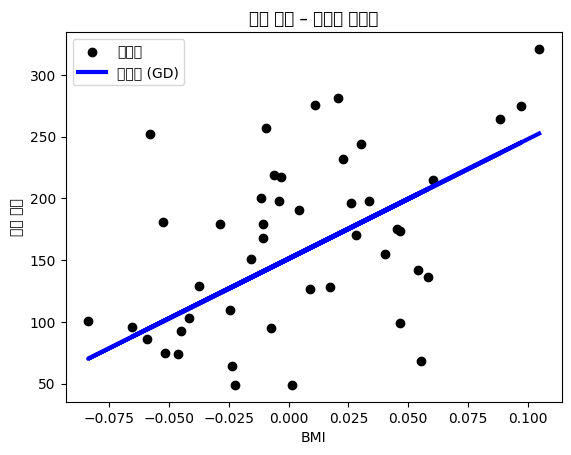

In [8]:
y_pred_test_final = W * X_test + b

plt.scatter(X_test, y_test, color='black', label='실제값')
plt.plot(X_test, y_pred_test_final, color='blue', linewidth=3, label='예측값 (GD)')
plt.title("선형 회귀 – 테스트 데이터")
plt.xlabel("BMI")
plt.ylabel("혈당 수치")
plt.legend()
plt.show()


### 6-3. 손실 곡선 (전체 epoch)

손실이 단조 감소하면 경사하강법이 정상적으로 수렴하고 있음을 의미함.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


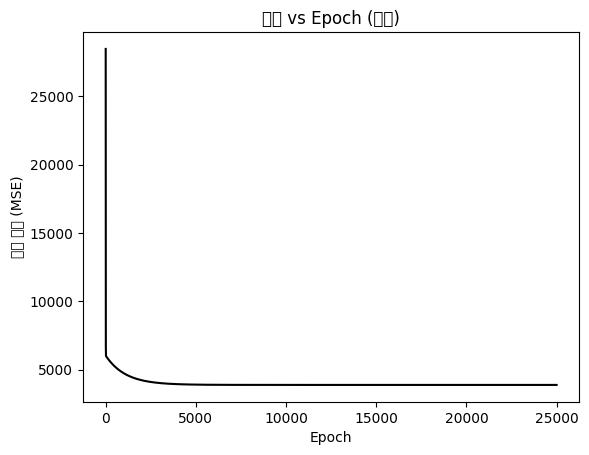

In [9]:
plt.plot(np.arange(epochs), train_loss, color='black')
plt.title("손실 vs Epoch (전체)")
plt.xlabel("Epoch")
plt.ylabel("학습 손실 (MSE)")
plt.show()


### 6-4. 손실 곡선 (마지막 10,000 epoch)

후반부를 확대해서 수렴 여부를 더 자세히 확인함.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


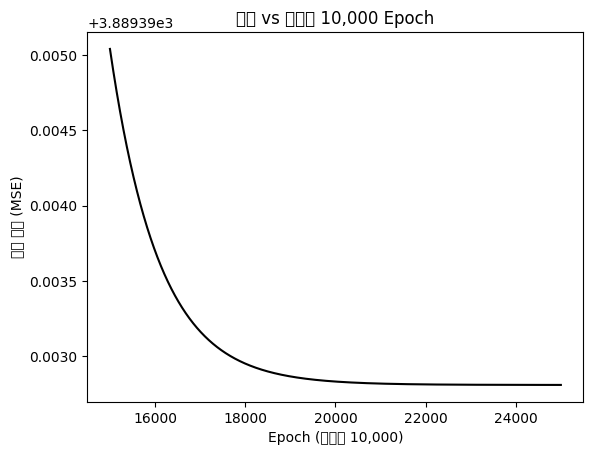

In [10]:
plt.plot(np.arange(epochs)[15000:], train_loss[15000:], color='black')
plt.title("손실 vs 마지막 10,000 Epoch")
plt.xlabel("Epoch (마지막 10,000)")
plt.ylabel("학습 손실 (MSE)")
plt.show()


---
## 7. 심화: 2차 다항 회귀 (Polynomial Regression)

모델을 2차 함수로 확장함:
$$\hat{y} = W_2 x^2 + W_1 x + W_0$$

각 파라미터의 기울기:
$$\frac{\partial L}{\partial W_2} = \frac{2}{n}\sum(\hat{y}-y)\cdot x^2, \quad
\frac{\partial L}{\partial W_1} = \frac{2}{n}\sum(\hat{y}-y)\cdot x, \quad
\frac{\partial L}{\partial W_0} = \frac{2}{n}\sum(\hat{y}-y)$$


학습된 파라미터 (2차 다항 회귀)
  W2 = 34.5836,  W1 = 965.7174,  W0 = 151.1295


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


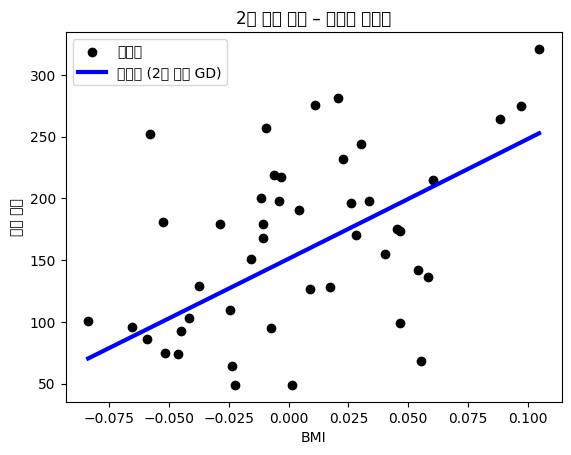

In [11]:
# ── 하이퍼파라미터 ───────────────────────────────────────────────
epochs_poly = 25000
lr_poly     = 0.1
n_poly      = float(len(X_train))

# ── 파라미터 초기화 ──────────────────────────────────────────────
np.random.seed(42)
W2 = np.random.rand()
W1 = np.random.rand()
W0 = np.random.rand()

poly_loss = []

# ── 학습 반복문 ──────────────────────────────────────────────────
for k in range(epochs_poly):

    # 순전파
    y_pred_poly = W2 * X_train**2 + W1 * X_train + W0

    # 손실 계산
    loss = (1 / n_poly) * np.sum((y_pred_poly - y_train) ** 2)
    poly_loss.append(loss)

    # 기울기 계산
    residual = y_pred_poly - y_train
    dW2 = (2 / n_poly) * np.sum(residual * X_train**2)
    dW1 = (2 / n_poly) * np.sum(residual * X_train)
    dW0 = (2 / n_poly) * np.sum(residual)

    # 파라미터 업데이트
    W2 -= lr_poly * dW2
    W1 -= lr_poly * dW1
    W0 -= lr_poly * dW0

print(f"학습된 파라미터 (2차 다항 회귀)")
print(f"  W2 = {W2:.4f},  W1 = {W1:.4f},  W0 = {W0:.4f}")

# ── 테스트 셋 시각화 ─────────────────────────────────────────────
X_test_sorted = np.sort(X_test)
y_poly_curve  = W2 * X_test_sorted**2 + W1 * X_test_sorted + W0

plt.scatter(X_test, y_test, color='black', label='실제값')
plt.plot(X_test_sorted, y_poly_curve, color='blue', linewidth=3, label='예측값 (2차 다항 GD)')
plt.title("2차 다항 회귀 – 테스트 데이터")
plt.xlabel("BMI")
plt.ylabel("혈당 수치")
plt.legend()
plt.show()


---
## 정리

| | sklearn | 경사하강법 (직접 구현) |
|---|---|---|
| **방법** | 정규 방정식 (Closed-form) | 반복 최적화 (Iterative) |
| **필요 epoch** | 1회 (즉시) | 25,000회 |
| **W** | ~966.7 | ~966.7 |
| **b** | ~151.2 | ~151.2 |



**핵심**: 두 방법 모두 동일한 최적 파라미터에 수렴함.  
경사하강법은 닫힌 해(closed-form solution)가 존재하지 않는 고차원 딥러닝 모델의 기반이 되는 알고리즘임.
